# 1. Data Loading

In [ ]:
# RE-RUN

from google.colab import drive

drive.mount('/content/drive/')
PROJECT_DIR = "/content/drive/MyDrive/aptos_project"
DATA_DIR = f"{PROJECT_DIR}/data"

Mounted at /content/drive/


#2. Data Exploration

In [ ]:
# RE-RUN

import pandas as pd

train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")

train_df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [ ]:
# test_df.head()

,id_code
0,0005cfc8afb6
1,003f0afdcd15
2,006efc72b638
3,00836aaacf06
4,009245722fa4


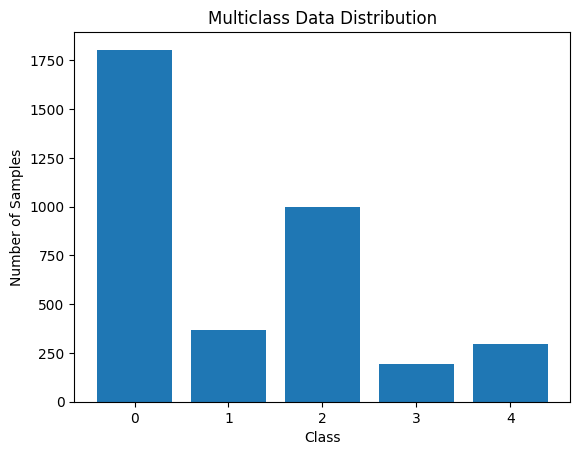

In [ ]:
# from collections import Counter
# import matplotlib.pyplot as plt

# count = Counter(train_df['diagnosis'])

# plt.bar(count.keys(), count.values())
# plt.title('Multiclass Data Distribution')
# plt.xlabel('Class')
# plt.ylabel('Number of Samples')
# plt.show()

Class imbalance - since 0 indicates no DR and 1-4 indicates presence of DR, we can first investigate whether a model can detect presence of DR with binary classification.

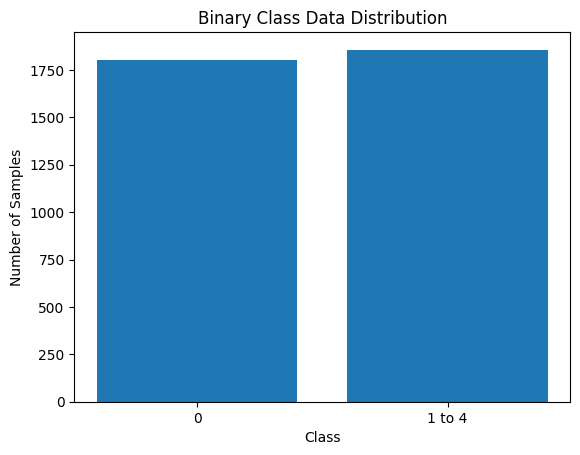

In [ ]:
# grouped = Counter({"0": count[0],
#     "1 to 4": count[1] + count[2] + count[3] + count[4]
# })
# grouped

# plt.bar(list(grouped.keys()), grouped.values())
# plt.title("Binary Class Data Distribution")
# plt.xlabel('Class')
# plt.ylabel('Number of Samples')
# plt.show()

# 3. Data Cleaning Functionality

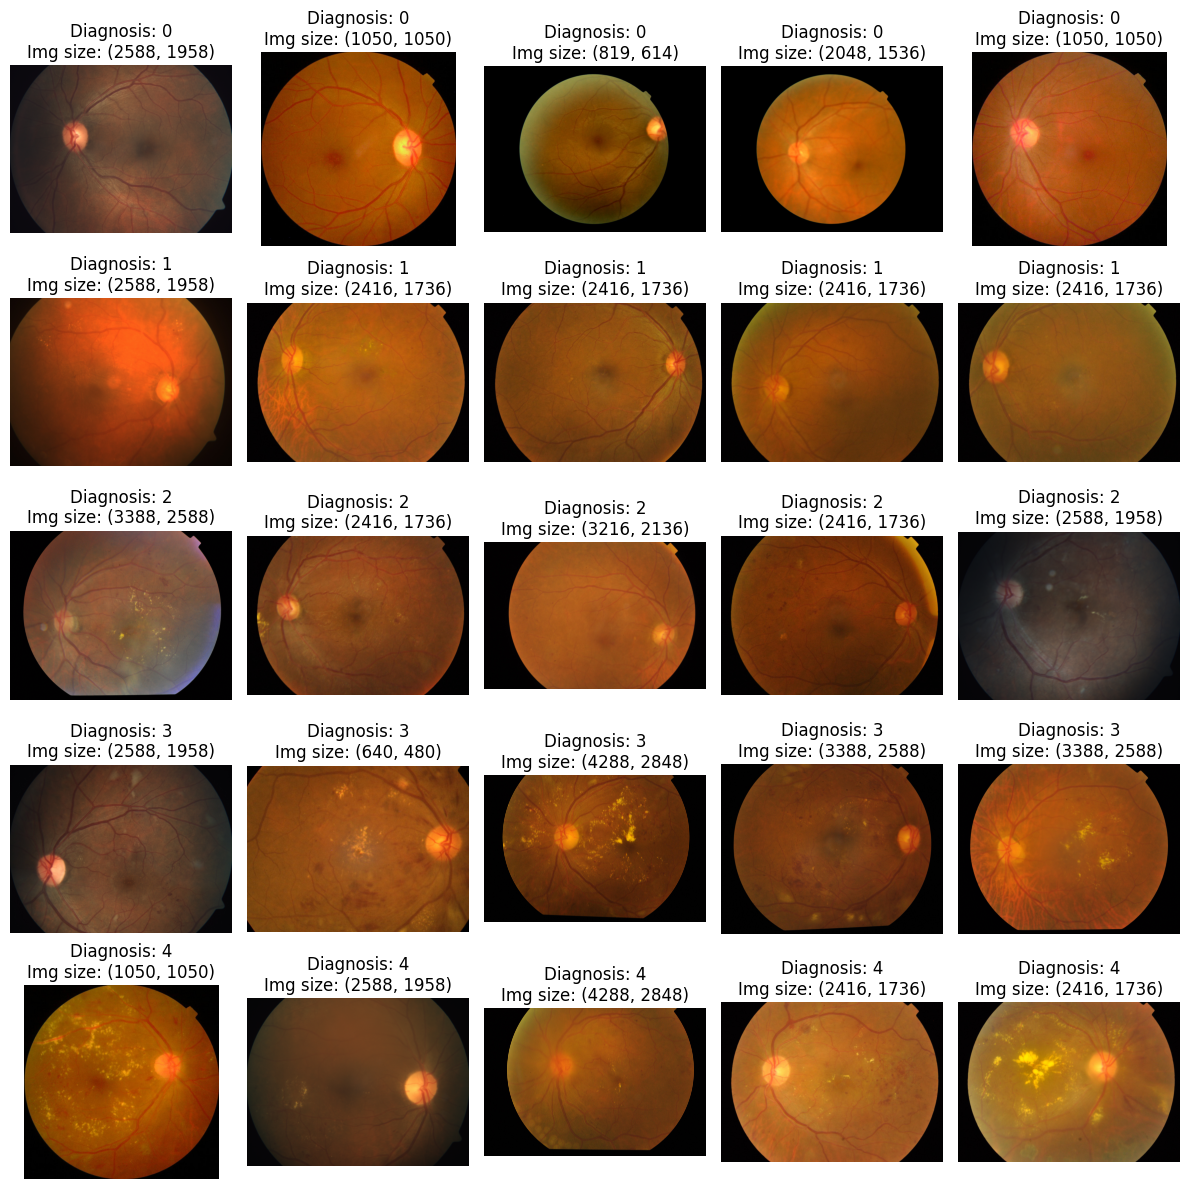

['/content/drive/MyDrive/aptos_project/data/train_images/a6356a3c5d11.png', '/content/drive/MyDrive/aptos_project/data/train_images/f3a4751af42e.png', '/content/drive/MyDrive/aptos_project/data/train_images/da0a83f074f3.png', '/content/drive/MyDrive/aptos_project/data/train_images/ad1aa75d5630.png', '/content/drive/MyDrive/aptos_project/data/train_images/b9bc81fcb075.png', '/content/drive/MyDrive/aptos_project/data/train_images/8676427e4625.png', '/content/drive/MyDrive/aptos_project/data/train_images/36677b70b1ef.png', '/content/drive/MyDrive/aptos_project/data/train_images/76be29bb30b2.png', '/content/drive/MyDrive/aptos_project/data/train_images/fe674c2f73f5.png', '/content/drive/MyDrive/aptos_project/data/train_images/2d9d97a6e713.png', '/content/drive/MyDrive/aptos_project/data/train_images/803120c5d287.png', '/content/drive/MyDrive/aptos_project/data/train_images/9a78c6a7b1c2.png', '/content/drive/MyDrive/aptos_project/data/train_images/6e68e742f5bc.png', '/content/drive/MyDrive/

In [ ]:
# from PIL import Image

# # view 5 random images from each diagnosis category
# fig, axes = plt.subplots(5, 5, figsize=(12, 12))

# png_files = []
# labels = []

# for i in range(5):
#     samples = train_df[train_df["diagnosis"] == i].sample(n=5, random_state=1)["id_code"]

#     for sample in samples:
#         png_files.append(f"{DATA_DIR}/train_images/{sample}.png")
#         labels.append(i)

# for ax, img_path, label in zip(axes.ravel(), png_files, labels):
#     img = Image.open(img_path)
#     ax.imshow(img)
#     ax.set_title(f"Diagnosis: {label}\n"
#                  f"Img size: {img.size}")
#     ax.axis("off")

# plt.tight_layout()
# plt.show()
# print(png_files)

Considerations:
1.   Different image sizes - CNNs need consistent image input sizes.
2.   Different colors - different cameras can pick up different lighting and clarity, the model may learn camera differences instead of disease features.
3.   Black border - not medically useful and the model again may learn patterns in black borders.
4.   Class imbalance - will first attempt to fit a binary classifier because binary classes (DR vs. No DR) are balanced



In [ ]:
# RE-RUN

import cv2
import numpy as np

def crop_retina(im, tol=20, pad=10):
    # make sure image is RGB
    im = im.convert("RGB")
    arr = np.array(im)

    # convert to grayscale
    gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)

    # find non-black pixels
    mask = gray > tol

    # If image is somehow empty, return original
    if not mask.any():
        return im

    # find coordinates of non-black region
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    # add padding so we do not crop into the retina
    y0 = max(y0 - pad, 0)
    x0 = max(x0 - pad, 0)
    y1 = min(y1 + pad, arr.shape[0])
    x1 = min(x1 + pad, arr.shape[1])

    # crop image
    cropped = im.crop((x0, y0, x1, y1))

    return cropped

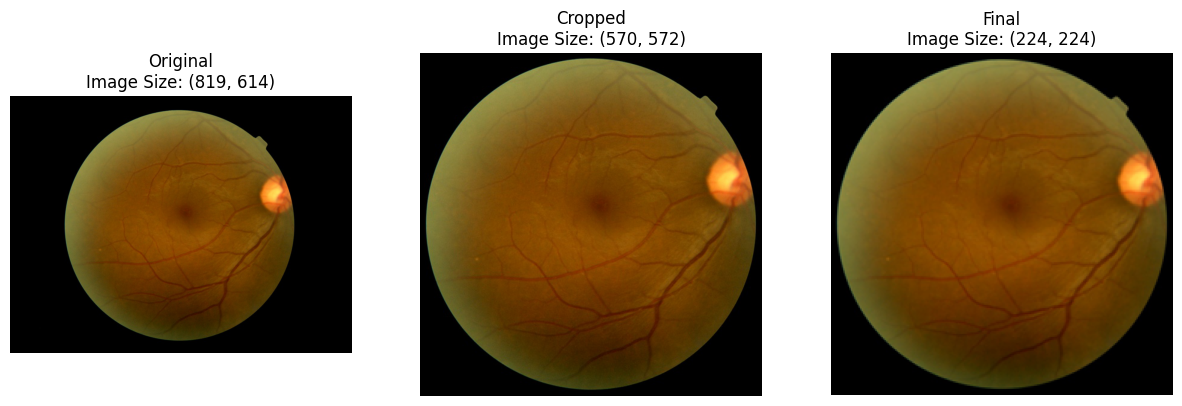

In [ ]:
# path = "/content/drive/MyDrive/aptos_project/data/train_images/da0a83f074f3.png" # example to crop

# img = Image.open(path).convert("RGB")
# cropped = crop_retina(img, tol=20, pad=10)
# final_img = cropped.resize((224, 224))

# plt.figure(figsize=(15, 5))

# plt.subplot(1, 3, 1)
# plt.imshow(img)
# plt.title("Original\n"
#           f"Image Size: {img.size}")
# plt.axis("off")

# plt.subplot(1, 3, 2)
# plt.imshow(cropped)
# plt.title("Cropped\n"
#         f"Image Size: {cropped.size}")
# plt.axis("off")

# plt.subplot(1, 3, 3)
# plt.imshow(final_img)
# plt.title("Final\n"
#         f"Image Size: {final_img.size}")
# plt.axis("off")

# plt.show()

# 4. Binary Classifier

## 4.1 Load Data

In [ ]:
# train_df["binary_label"] = train_df["diagnosis"].apply(lambda x: 0 if x == 0 else 1)
# train_df["binary_label"].value_counts()

In [ ]:
# # RE-RUN

# from sklearn.model_selection import train_test_split

# # binary label: 0 = no DR, 1 = any DR
# train_df["binary_label"] = train_df["diagnosis"].apply(lambda x: 0 if x == 0 else 1)

# # provided train_images set is labeled, provided test_images set is unlabeled
# # first split off labeled test set from labeled set: 20%
# train_val_df, test_df = train_test_split(
#     train_df,
#     test_size=0.2,
#     stratify=train_df["binary_label"],
#     random_state=42
# )

# # then split remaining labeled set into train/val
# train_data, val_data = train_test_split(
#     train_val_df,
#     test_size=0.2,
#     stratify=train_val_df["binary_label"],
#     random_state=42
# )

# train_data.shape, val_data.shape, test_df.shape
# train_data.head()

In [ ]:
# # RE-RUN

# from torch.utils.data import Dataset
# from PIL import Image
# from torchvision import transforms

# class APTOSDataset(Dataset):
#     def __init__(self, dataframe, img_dir, transform=None):
#         self.dataframe = dataframe.reset_index(drop=True)
#         self.img_dir = img_dir
#         self.transform = transform

#     def __len__(self):
#         return len(self.dataframe)

#     def __getitem__(self, idx):
#         img_id = self.dataframe.loc[idx, "id_code"]
#         img_path = os.path.join(self.img_dir, img_id + ".png")
#         image = Image.open(img_path).convert("RGB")

#         # crop black border
#         image = crop_retina(image, tol=20, pad=10)

#         label = self.dataframe.loc[idx, "binary_label"]

#         if self.transform:
#             image = self.transform(image)

#         return image, label


# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     # random augmentations for training only
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(10),
#     transforms.ColorJitter(
#         brightness=0.2,
#         contrast=0.2,
#         saturation=0.2
#     ),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
# ])

# val_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
# ])


In [ ]:
# # RE-RUN

# import os

# IMG_DIR = f"{DATA_DIR}/train_images"

# train_dataset = APTOSDataset(train_data, IMG_DIR, transform=train_transform)
# val_dataset = APTOSDataset(val_data, IMG_DIR, transform=val_transform)
# test_dataset = APTOSDataset(test_df, IMG_DIR, transform=val_transform)

# img, label = train_dataset[0]

# print(type(img))
# print(img.shape)
# print(label)


In [ ]:
# # RE-RUN

# from torch.utils.data import DataLoader

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=16,
#     shuffle=True,
#     num_workers=2
# )

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=16,
#     shuffle=False,
#     num_workers=2
# )

# test_loader = DataLoader(
#     test_dataset,
#     batch_size=16,
#     shuffle=False,
#     num_workers=2
# )

## 4.2 Train and Calculate Validation Error

In [ ]:
# # RE-RUN

# def train(epoch_num):
#   model.train()

#   running_loss = 0.0
#   progress_bar = tqdm(train_loader, desc=f"Epoch {epoch_num + 1}")

#   for images, labels in progress_bar:
#       images = images.to(device)
#       labels = labels.to(device)

#       optimizer.zero_grad()

#       # forward pass - make prediction and calculate loss
#       outputs = model(images)
#       loss = criterion(outputs, labels)

#       # backward pass - calculate gradients and update weights
#       loss.backward()
#       optimizer.step()

#       running_loss += loss.item()

#       # update progress bar text
#       progress_bar.set_postfix(loss=loss.item())

#   avg_loss = running_loss / len(train_loader)

#   print(f"Epoch {epoch_num + 1}, average training loss across batches: {avg_loss:.4f}")


In [ ]:
# # RE-RUN

# def calculate_validation_error(epoch_num):
#   model.eval()

#   running_loss = 0.0
#   progress_bar = tqdm(val_loader, desc=f"Epoch {epoch_num + 1}")

#   with torch.no_grad():
#     for images, labels in progress_bar:
#       images = images.to(device)
#       labels = labels.to(device)

#       # forward pass - make prediction and calculate loss
#       outputs = model(images)
#       loss = criterion(outputs, labels)

#       running_loss += loss.item()

#       # update progress bar text
#       progress_bar.set_postfix(loss=loss.item())

#   avg_loss = running_loss / len(val_loader)

#   print(f"Epoch {epoch_num + 1}, average validation loss across batches: {avg_loss:.4f}")


In [ ]:
# # RE-RUN

# import torch
# import torch.nn as nn
# from torchvision import models
# import torch.optim as optim
# from tqdm.notebook import tqdm

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(device)

# # load ImageNet weights
# model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# # freeze ImageNet layers (all the layers except the final one)
# for param in model.parameters():
#     param.requires_grad = False

# # replace final layer for binary classification
# model.fc = nn.Linear(model.fc.in_features, 2)

# model = model.to(device)

# criterion = nn.CrossEntropyLoss()

# # specify learning algorithm including learning rate
# optimizer = optim.Adam(model.parameters(), lr=1e-4)

# # specify passes over training set
# num_epochs = 3

# for epoch in range(num_epochs):
#     train(epoch)
#     calculate_validation_error(epoch)


# 5. Pre-training Model Backbone

using a cropped subset of 2000 images from the training set of an ocular disease recognition dataset (https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k)

## 5.1 Set Up Pre-training Model

In [ ]:
# RE-RUN

from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

# unsupervised - no labels
# want model to learn which perturbed images are connected
class PretrainDataset(Dataset):
  def __init__(self, dataframe, img_dir, transform):
    self.dataframe = dataframe.reset_index(drop=True)
    self.img_dir = img_dir
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    img_id = self.dataframe.loc[idx, "id_code"]
    img_path = os.path.join(self.img_dir, img_id + ".jpg")
    image = Image.open(img_path)

    transformed_image_1 = self.transform(image)
    transformed_image_2 = self.transform(image)

    return transformed_image_1, transformed_image_2


pretrain_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [ ]:
# RE-RUN

import torch.nn as nn

class PretrainModel(nn.Module):

  # image (perturbed) --> backbone --> projection head (linear, RELU, linear) --> 128-dimension embedding

  def __init__(self, backbone):
    super().__init__()
    self.backbone = backbone
    self.projection_head = nn.Sequential(
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Linear(256, 128)
        )

  def forward(self, x):
    features = self.backbone(x)
    projection = self.projection_head(features)

    return projection

In [ ]:
# RE-RUN

class PretrainLoss(nn.Module):
  def __init__(self, temperature=0.5):
    super().__init__()
    self.temperature = temperature

  def forward(self, z1, z2):
    N = z1.shape[0]

    # normalize perturbed embeddings (two per image)
    z1 = nn.functional.normalize(z1, dim=1)
    z2 = nn.functional.normalize(z2, dim=1)

    # concatenate all perturbed embeddings into one matrix (2N, 128)
    z = torch.cat([z1, z2], dim=0)

    # compute similarity matrix for every perturbed embedding vs. every other (2N, 2N), omitting self-similarity
    similarity = torch.matmul(z, z.T) / self.temperature
    mask = torch.eye(2*N, dtype=torch.bool).to(z.device)
    similarity.masked_fill_(mask, float('-inf'))

    # ground truth labels — for each perturbed embedding, its connected embedding is N positions away (0 -> N, 1 -> N+1, ..., N-1 -> 2N-1)
    labels = torch.cat([torch.arange(N, 2*N), torch.arange(N)]).to(z.device)

    loss = nn.functional.cross_entropy(similarity, labels)

    return loss

## 5.2 Load Data

In [ ]:
# RE-RUN

from PIL import Image
import os
import pandas as pd
import random

# cropped using crop_retina function
CROPPED_IMG_DIR = f"{DATA_DIR}/cropped_pretrain_images"

img_ids = [f.replace(".jpg", "") for f in os.listdir(CROPPED_IMG_DIR) if f.endswith(".jpg")]
pretrain_data = pd.DataFrame({"id_code": img_ids})

In [ ]:
# RE-RUN

from torch.utils.data import DataLoader

pretrain_dataset = PretrainDataset(pretrain_data, CROPPED_IMG_DIR, transform=pretrain_transform)
pretrain_loader = DataLoader(
    pretrain_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

## 5.3 Train

In [ ]:
# RE-RUN

def pretrain(epoch_num):
  pretrain_model.train()

  running_loss = 0.0
  progress_bar = tqdm(pretrain_loader, desc=f"Epoch {epoch_num + 1}")

  for (perturbed_image_1, perturbed_image_2) in progress_bar:

    perturbed_image_1 = perturbed_image_1.to(device)
    perturbed_image_2 = perturbed_image_2.to(device)

    pretrain_optimizer.zero_grad()

    # forward pass - make prediction and calculate loss
    embedding_1 = pretrain_model(perturbed_image_1)
    embedding_2 = pretrain_model(perturbed_image_2)
    loss = pretrain_criterion(embedding_1, embedding_2)

    # backward pass - calculate gradients and update weights
    loss.backward()
    pretrain_optimizer.step()

    running_loss += loss.item()

    # update progress bar text
    progress_bar.set_postfix(loss=loss.item())

  avg_loss = running_loss / len(pretrain_loader)

  print(f"Epoch {epoch_num + 1}, average pretraining loss across batches: {avg_loss:.4f}")


In [ ]:
# RE-RUN

import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# use ImageNet weights
backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
backbone.fc = nn.Identity()

pretrain_model = PretrainModel(backbone).to(device)
pretrain_criterion = PretrainLoss(temperature=0.5)
pretrain_optimizer = optim.Adam(pretrain_model.parameters(), lr=1e-4)

# specify passes over pre-training set
num_epochs = 10

for epoch in range(num_epochs):
    pretrain(epoch)

torch.save(pretrain_model.state_dict(), f"{PROJECT_DIR}/pretrain_model_weights.pth")



cuda


Epoch 1:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1, average pretraining loss across batches: 3.0455


Epoch 2:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2, average pretraining loss across batches: 2.6343


...

Epoch 8, average pretraining loss across batches: 2.4234


Epoch 9:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 9, average pretraining loss across batches: 2.4141


Epoch 10:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 10, average pretraining loss across batches: 2.4016


# 6. Fine-tuning Model

using a cropped subset of labeled images from the training set of our primary dataset (https://www.kaggle.com/c/aptos2019-blindness-detection)

## 6.1 Load Data

In [ ]:
# RE-RUN

from sklearn.model_selection import train_test_split

# provided train_images set is labeled, provided test_images set is unlabeled
# first split off labeled test set from labeled set: 20%
train_val_df, test_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["diagnosis"],
    random_state=42
)

# then split remaining labeled set into train/val
train_data, val_data = train_test_split(
    train_val_df,
    test_size=0.2,
    stratify=train_val_df["diagnosis"],
    random_state=42
)

train_data.shape, val_data.shape, test_df.shape
train_data.head()

,id_code,diagnosis
959,44a4d04162cc,0
831,3bf3085ac167,0
2156,97f290d31813,0
1318,5b76117c4bcb,4
716,338326891d84,0


In [ ]:
# RE-RUN

from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

class APTOSDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_id = self.dataframe.loc[idx, "id_code"]
        img_path = os.path.join(self.img_dir, img_id + ".png")
        image = Image.open(img_path).convert("RGB")

        label = self.dataframe.loc[idx, "diagnosis"]

        if self.transform:
            image = self.transform(image)

        return image, label


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # random augmentations for training only
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
TRAIN_DIR = f"{DATA_DIR}/train_images"
CROPPED_TRAIN_DIR = f"{DATA_DIR}/cropped_train_images"

# for fname in os.listdir(TRAIN_DIR):
#   if fname.endswith(".png"):
#     img = Image.open(os.path.join(TRAIN_DIR, fname)).convert("RGB")
#     cropped = crop_retina(img, tol=20, pad=10)
#     cropped.save(os.path.join(CROPPED_TRAIN_DIR, fname))

In [ ]:
# RE-RUN

import os

train_dataset = APTOSDataset(train_data, CROPPED_TRAIN_DIR, transform=train_transform)
val_dataset = APTOSDataset(val_data, CROPPED_TRAIN_DIR, transform=val_transform)
test_dataset = APTOSDataset(test_df, CROPPED_TRAIN_DIR, transform=val_transform)

img, label = train_dataset[0]

print(type(img))
print(img.shape)
print(label)


<class 'torch.Tensor'>
torch.Size([3, 224, 224])
0


In [ ]:
# RE-RUN

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

## 6.2 Train and Calculate Validation Error

In [ ]:
# RE-RUN

def train(epoch_num):
  model.train()

  running_loss = 0.0
  progress_bar = tqdm(train_loader, desc=f"Epoch {epoch_num + 1}")

  for images, labels in progress_bar:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    # forward pass - make prediction and calculate loss
    outputs = model(images)
    loss = criterion(outputs, labels)

    # backward pass - calculate gradients and update weights
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    # update progress bar text
    progress_bar.set_postfix(loss=loss.item())

  avg_loss = running_loss / len(train_loader)

  print(f"Epoch {epoch_num + 1}, average training loss across batches: {avg_loss:.4f}")

In [ ]:
# RE-RUN

def calculate_validation_error(epoch_num):
  model.eval()

  running_loss = 0.0
  progress_bar = tqdm(val_loader, desc=f"Epoch {epoch_num + 1}")

  with torch.no_grad():
    for images, labels in progress_bar:
      images = images.to(device)
      labels = labels.to(device)

      # forward pass - make prediction and calculate loss
      outputs = model(images)
      loss = criterion(outputs, labels)

      running_loss += loss.item()

      # update progress bar text
      progress_bar.set_postfix(loss=loss.item())

  avg_loss = running_loss / len(val_loader)

  print(f"Epoch {epoch_num + 1}, average validation loss across batches: {avg_loss:.4f}")


In [ ]:
# RE-RUN

import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# load pre-trained backbone weights
backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1) # ImageNet weights overwritten when pre-trained backbone weights loaded
backbone.fc = nn.Identity()
pretrain_model = PretrainModel(backbone).to(device)

state_dict = torch.load(f"{PROJECT_DIR}/pretrain_model_weights.pth", weights_only=True)
pretrain_model.load_state_dict(state_dict)

model = pretrain_model.backbone.to(device)

# freeze pre-trained backbone layers (except the final layer)
for param in model.parameters():
  param.requires_grad = False

# replace final layer for DR classification
model.fc = nn.Linear(512, 5)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

# specify learning algorithm including learning rate
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# specify passes over training set
num_epochs = 10

for epoch in range(num_epochs):
  train(epoch)
  calculate_validation_error(epoch)

torch.save(model.state_dict(), f"{PROJECT_DIR}/model_weights.pth")


cuda


Epoch 1:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 1, average training loss across batches: 1.2755


Epoch 1:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 1, average validation loss across batches: 1.0293


...

Epoch 9, average validation loss across batches: 0.7920


Epoch 10:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 10, average training loss across batches: 0.8611


Epoch 10:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 10, average validation loss across batches: 0.7938


# 7 Inference on Test Set

In [ ]:
from sklearn.metrics import cohen_kappa_score

def evaluate(loader):
  model.eval()

  all_preds = []
  all_labels = []

  with torch.no_grad():
    for images, labels in loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      preds = torch.argmax(outputs, dim=1)

      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
  qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

  print(f"Accuracy: {accuracy:.4f}")
  print(f"Quadratic Weighted Kappa: {qwk:.4f}")

In [ ]:
evaluate(test_loader)

Accuracy: 0.6862
Quadratic Weighted Kappa: 0.6608
